<a href="https://colab.research.google.com/github/kailashscse2025-alt/DAA/blob/main/DAA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       STRING MATCHING ALGORITHMS

Text   : AABAACAADAABAABA
Pattern: AABA

------------- SEARCH RESULTS ----------------
Naive      -> Matches at: [0, 9, 12], Comparisons: 30
KMP        -> Matches at: [0, 9, 12], Comparisons: 20
Rabin-Karp -> Matches at: [0, 9, 12], Comparisons: 12


          PERFORMANCE COMPARISON
     Pattern        Naive          KMP           RK
----------------------------------------------------
          AB        12530        11891         1280
        ABCD        13310        12499          202
      ABCDAB        13348        12529          125
    ABCDABCD        13350        12531          138


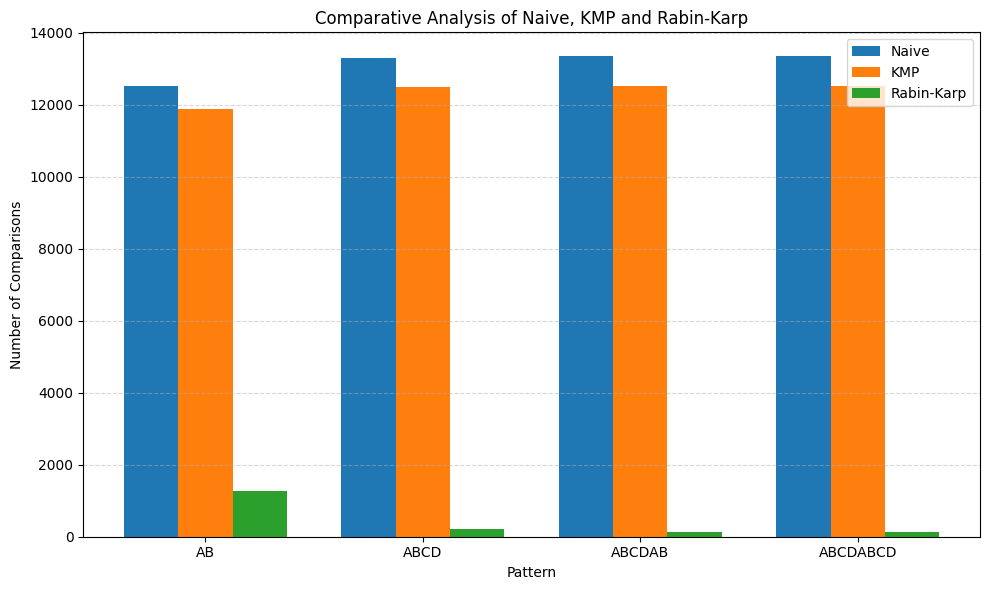

In [1]:
import random
import matplotlib.pyplot as plt


# ---------------- NAIVE SEARCH ----------------
def naive_search(text, pattern):
    n = len(text)
    m = len(pattern)

    matches = []
    comparisons = 0

    for i in range(n - m + 1):
        j = 0

        while j < m:
            comparisons += 1

            if text[i + j] != pattern[j]:
                break

            j += 1

        if j == m:
            matches.append(i)

    return matches, comparisons


# ---------------- COMPUTE LPS ----------------
def compute_lps(pattern):
    m = len(pattern)
    lps = [0] * m

    length = 0
    i = 1

    while i < m:
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1

        elif length != 0:
            length = lps[length - 1]

        else:
            lps[i] = 0
            i += 1

    return lps


# ---------------- KMP SEARCH ----------------
def kmp_search(text, pattern):
    n = len(text)
    m = len(pattern)

    if m == 0 or m > n:
        return [], 0

    lps = compute_lps(pattern)

    matches = []
    comparisons = 0

    i = 0
    j = 0

    while i < n:

        comparisons += 1

        if text[i] == pattern[j]:
            i += 1
            j += 1

            if j == m:
                matches.append(i - j)
                j = lps[j - 1]

        else:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return matches, comparisons


# ---------------- RABIN-KARP SEARCH ----------------
def rabin_karp(text, pattern, q=101):
    n = len(text)
    m = len(pattern)

    if m == 0 or m > n:
        return [], 0

    d = 256

    h = pow(d, m - 1, q)

    p_hash = 0
    t_hash = 0

    matches = []
    comparisons = 0

    # Initial hash
    for i in range(m):
        p_hash = (d * p_hash + ord(pattern[i])) % q
        t_hash = (d * t_hash + ord(text[i])) % q

    # Search
    for s in range(n - m + 1):

        if p_hash == t_hash:

            for k in range(m):
                comparisons += 1

                if text[s + k] != pattern[k]:
                    break

            else:
                matches.append(s)

        # Calculate next hash
        if s < n - m:

            t_hash = (
                d * (t_hash - ord(text[s]) * h)
                + ord(text[s + m])
            ) % q

            if t_hash < 0:
                t_hash += q

    return matches, comparisons


# ==================================================
# MAIN PROGRAM
# ==================================================

text = "AABAACAADAABAABA"
pattern = "AABA"

print("==============================================")
print("       STRING MATCHING ALGORITHMS")
print("==============================================")

print("\nText   :", text)
print("Pattern:", pattern)

# Run algorithms
m1, c1 = naive_search(text, pattern)
m2, c2 = kmp_search(text, pattern)
m3, c3 = rabin_karp(text, pattern)

print("\n------------- SEARCH RESULTS ----------------")

print(f"Naive      -> Matches at: {m1}, Comparisons: {c1}")
print(f"KMP        -> Matches at: {m2}, Comparisons: {c2}")
print(f"Rabin-Karp -> Matches at: {m3}, Comparisons: {c3}")


# ==================================================
# PERFORMANCE COMPARISON
# ==================================================

text_large = ''.join(random.choices("ABCD", k=10000))

patterns = [
    "AB",
    "ABCD",
    "ABCDAB",
    "ABCDABCD"
]

naive_results = []
kmp_results = []
rk_results = []

print("\n\n==============================================")
print("          PERFORMANCE COMPARISON")
print("==============================================")

print(f"{'Pattern':>12} {'Naive':>12} {'KMP':>12} {'RK':>12}")
print("-" * 52)

for p in patterns:

    _, c1 = naive_search(text_large, p)
    _, c2 = kmp_search(text_large, p)
    _, c3 = rabin_karp(text_large, p)

    naive_results.append(c1)
    kmp_results.append(c2)
    rk_results.append(c3)

    print(f"{p:>12} {c1:>12} {c2:>12} {c3:>12}")


# ==================================================
# GRAPH
# ==================================================

x = range(len(patterns))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width for i in x],
    naive_results,
    width,
    label="Naive"
)

plt.bar(
    x,
    kmp_results,
    width,
    label="KMP"
)

plt.bar(
    [i + width for i in x],
    rk_results,
    width,
    label="Rabin-Karp"
)

plt.xlabel("Pattern")
plt.ylabel("Number of Comparisons")

plt.title(
    "Comparative Analysis of Naive, KMP and Rabin-Karp"
)

plt.xticks(x, patterns)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()